In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Example of how regression estimates can differ from the truth

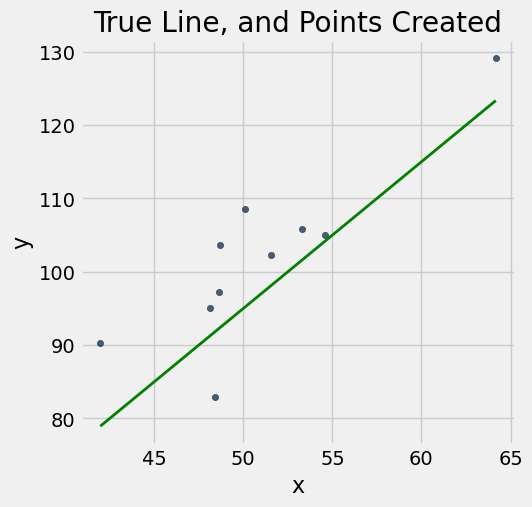

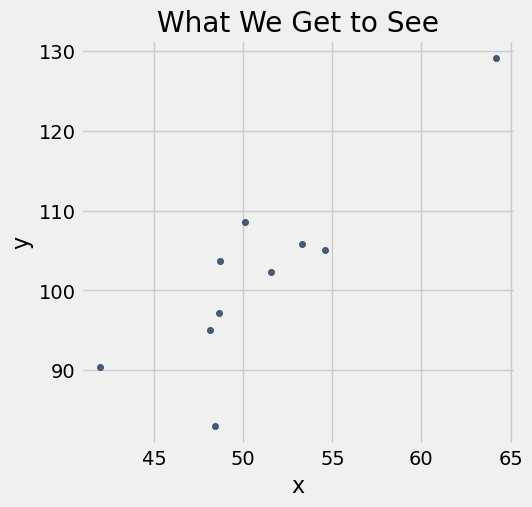

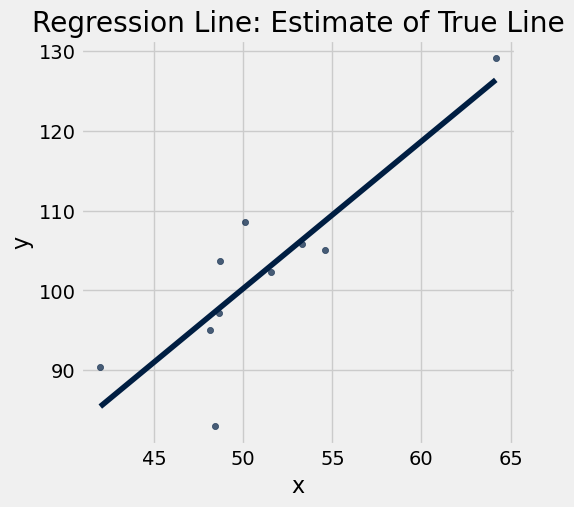

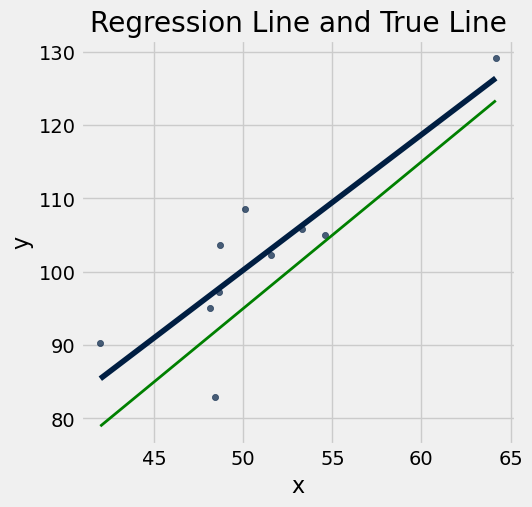

In [2]:
def draw_and_compare(true_slope, true_int, sample_size):
    x = np.random.normal(50, 5, sample_size)
    xlims = np.array([np.min(x), np.max(x)])
    errors = np.random.normal(0, 6, sample_size)
    y = (true_slope * x + true_int) + errors
    sample = Table().with_columns('x', x, 'y', y)

    sample.scatter('x', 'y')
    plt.plot(xlims, true_slope*xlims + true_int, lw=2, color='green')
    plt.title('True Line, and Points Created')

    sample.scatter('x', 'y')
    plt.title('What We Get to See')

    sample.scatter('x', 'y', fit_line=True)
    plt.title('Regression Line: Estimate of True Line')

    sample.scatter('x', 'y', fit_line=True)
    plt.plot(xlims, true_slope*xlims + true_int, lw=2, color='green')
    plt.title("Regression Line and True Line")

draw_and_compare(true_slope=2, true_int=-5, sample_size=10)

# Regression Prediction

In [3]:
def standard_units(arr):
    return (arr - np.average(arr))/np.std(arr)

def correlation(t, x, y):
    x_standard = standard_units(t.column(x))
    y_standard = standard_units(t.column(y))
    return np.average(x_standard * y_standard)

def slope(t, x, y):
    r = correlation(t, x, y)
    y_sd = np.std(t.column(y))
    x_sd = np.std(t.column(x))
    return r * y_sd / x_sd

def intercept(t, x, y):
    x_mean = np.mean(t.column(x))
    y_mean = np.mean(t.column(y))
    return y_mean - slope(t, x, y)*x_mean

def fitted_values(t, x, y):
    """Return an array of the regression estimates at all the x values"""
    m = slope(t, x, y)
    b = intercept(t, x, y)
    return m*t.column(x) + b

def residuals(t, x, y):
    """Return an array of all the residuals"""
    predictions = fitted_values(t, x, y)
    return t.column(y) - predictions

In [4]:
births = Table.read_table('data/baby.csv')
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


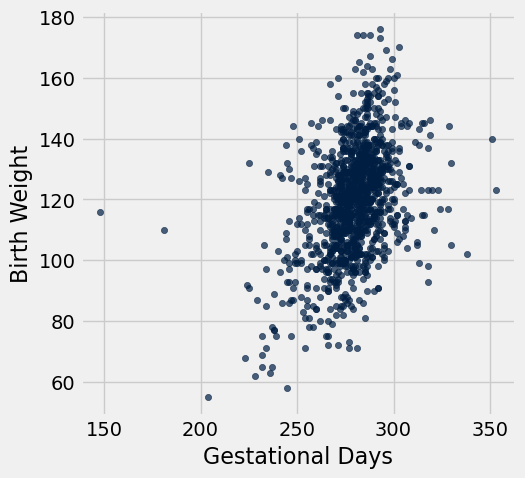

In [6]:
births.scatter('Gestational Days', 'Birth Weight')

In [7]:
correlation(births, 'Gestational Days', 'Birth Weight')

0.40754279338885108

In [8]:
# According to the CDC, preterm and postterm pregnancy cutoffs
37 * 7, 42 * 7

(259, 294)

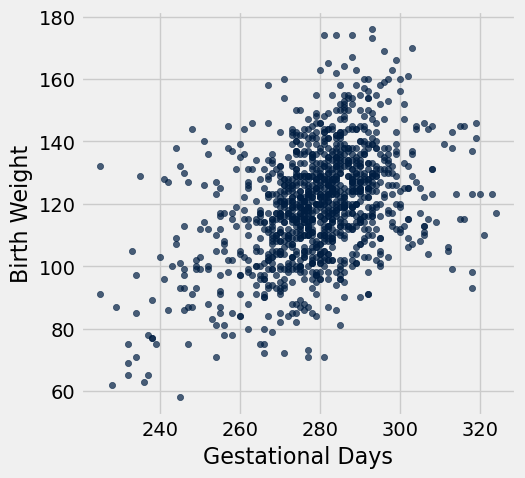

In [10]:
births = births.where('Gestational Days', are.between(225, 325))
births.scatter('Gestational Days', 'Birth Weight')

In [11]:
correlation(births, 'Gestational Days', 'Birth Weight')

0.42295118452423991

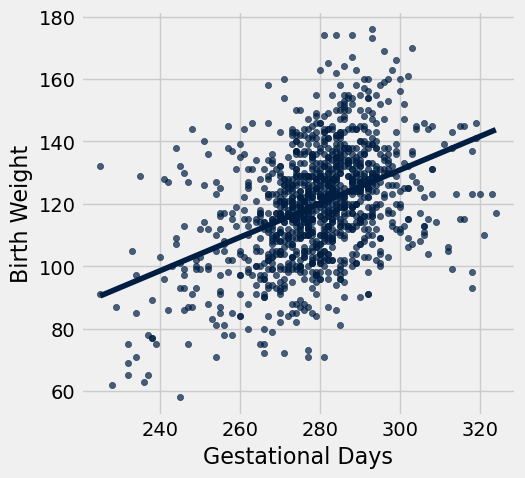

In [12]:
births.scatter('Gestational Days', 'Birth Weight', fit_line=True)

In [13]:
# Goal: can we estimate the *true* relationship between x and y?

In [14]:
slope(births, 'Gestational Days', 'Birth Weight')

0.53784536766790358

Slope of regression line: 0.538
Approximate 95%-confidence interval for the slope of the true line:
0.458 to 0.617


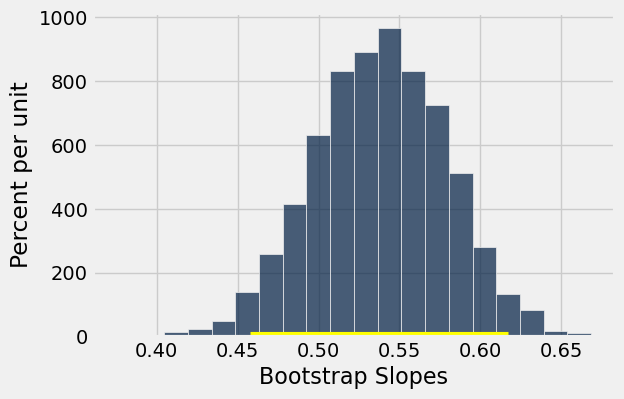

In [15]:
repetitions = 2500

# create 2500 bootstrap samples, find the slopes, and save them all
slopes = make_array()
for i in np.arange(repetitions):
    bootstrap_sample = births.sample()
    bootstrap_slope = slope(bootstrap_sample, 'Gestational Days', 'Birth Weight')
    slopes = np.append(slopes, bootstrap_slope)

# find the endpoints of the 95% confidence interval for the true slope
left = percentile(2.5, slopes)
right = percentile(97.5, slopes)

# slope of the regression line from the original sample
observed_slope = slope(births, 'Gestational Days', 'Birth Weight')

# Display results (you don't have to understand this code)
Table().with_column('Bootstrap Slopes', slopes).hist(bins=20)
plt.plot(make_array(left, right), make_array(0, 0), color='yellow', lw=8);
print('Slope of regression line:', round(observed_slope, 3))
print('Approximate 95%-confidence interval for the slope of the true line:')
print(round(left, 3), 'to', round(right, 3))

In [16]:
def bootstrap_slope_interval(t, x, y, repetitions=2500):
    # create 2500 bootstrap samples, find the slopes, and save them all
    slopes = make_array()
    for i in np.arange(repetitions):
        bootstrap_sample = t.sample()
        bootstrap_slope = slope(bootstrap_sample, x, y)
        slopes = np.append(slopes, bootstrap_slope)
    
    # find the endpoints of the 95% confidence interval for the true slope
    left = percentile(2.5, slopes)
    right = percentile(97.5, slopes)
    
    # slope of the regression line from the original sample
    observed_slope = slope(t, x, y)
    
    # Display results (you don't have to understand this code)
    Table().with_column('Bootstrap Slopes', slopes).hist(bins=20)
    plt.plot(make_array(left, right), make_array(0, 0), color='yellow', lw=8);
    print('Slope of regression line:', round(observed_slope, 3))
    print('Approximate 95%-confidence interval for the slope of the true line:')
    print(round(left, 3), 'to', round(right, 3))

Slope of regression line: 0.538
Approximate 95%-confidence interval for the slope of the true line:
0.459 to 0.62


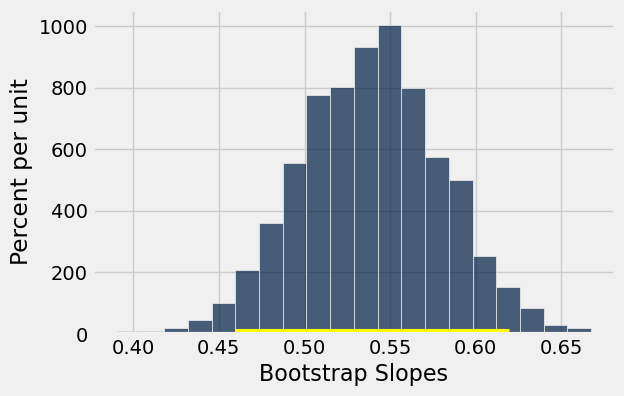

In [17]:
bootstrap_slope_interval(births, 'Gestational Days', 'Birth Weight', 3000)

In [18]:
# Goal: predict a confidence interval for someone who's not in our sample
# We have data for 300 gestational days, but it's all over the place and only for
# the people in our sample.
# Let's do a bootstrap to see how the prediction changes

In [19]:
def prediction_at(t, x, y, x_value):
    '''
    t: table
    x: label of the x column
    y: label of the y column
    x_value: the x value for which we want to predict y
    '''
    return slope(t, x, y)*x_value + intercept(t, x, y)

In [20]:
prediction_at_300 = prediction_at(births, 'Gestational Days', 'Birth Weight', 300)
prediction_at_300

130.80951674248769

## Visual example: different bootstrap samples will give different estimates

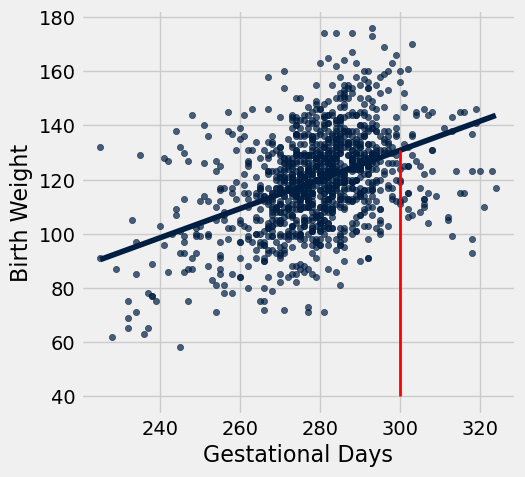

In [21]:
x = 300
births.scatter('Gestational Days', 'Birth Weight', fit_line=True)
plt.plot([x, x], [40, prediction_at_300], color='red', lw=2);

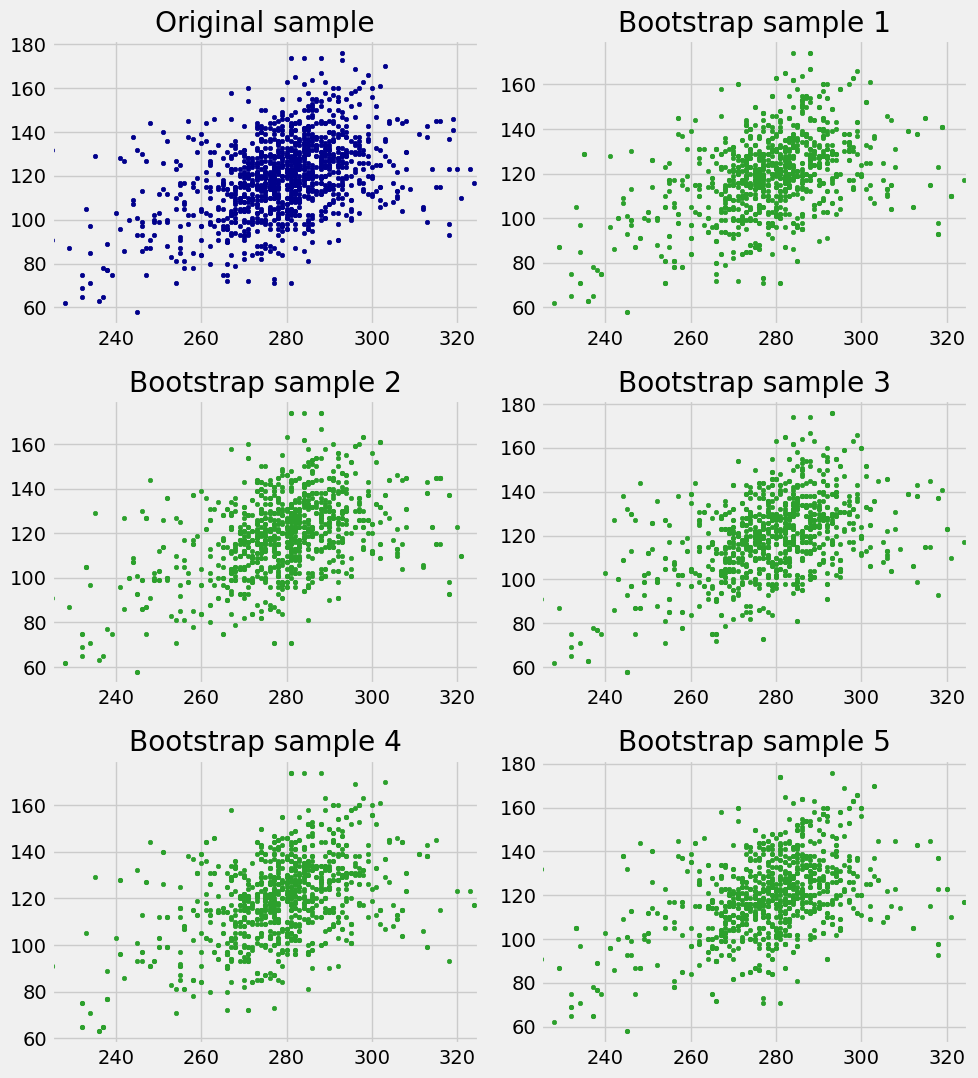

In [22]:
# 5 bootstrap samples
plt.figure(figsize=(10, 11))
plt.subplot(3, 2, 1)
plt.scatter(births[1], births[0], s=10, color='darkblue')
plt.xlim([225, 325])
plt.title('Original sample')

for i in np.arange(1, 6, 1):
    plt.subplot(3,2,i+1)
    resampled = births.sample()
    plt.scatter(resampled.column('Gestational Days'), resampled.column('Birth Weight'), s=10, color='tab:green')
    plt.xlim([225, 325])
    plt.title('Bootstrap sample '+str(i))
plt.tight_layout()

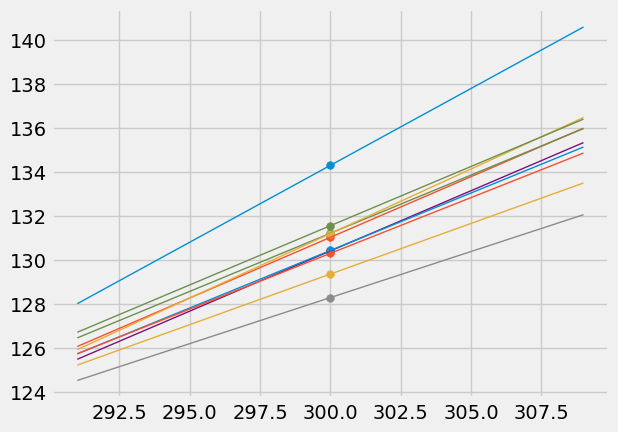

In [23]:
# 10 bootstrap predictions
x = 300

lines = Table(['slope','intercept'])
for i in range(10):
    rep = births.sample(with_replacement=True)
    a = slope(rep, 'Gestational Days', 'Birth Weight')
    b = intercept(rep, 'Gestational Days', 'Birth Weight')
    lines.append([a, b])

lines['prediction at x='+str(x)] = lines.column('slope')*x + lines.column('intercept')

xlims = np.array([291, 309])
left = xlims[0]*lines[0] + lines[1]
right = xlims[1]*lines[0] + lines[1]
fit_x = x*lines['slope'] + lines['intercept']

for i in range(10):
    plt.plot(xlims, np.array([left[i], right[i]]), lw=1)
    plt.scatter(x, fit_x[i], s=30)

In [24]:
lines

slope,intercept,prediction at x=300
0.698367,-75.2121,134.298
0.551104,-34.3033,131.028
0.45962,-8.5263,129.36
0.528373,-27.2976,131.214
0.41842,2.76488,128.291
0.546925,-33.6672,130.41
0.522319,-26.2649,130.431
0.506342,-21.6015,130.301
0.585926,-44.5776,131.2
0.537926,-29.8207,131.557


In [26]:
# Bootstrap prediction of variable y at new_x
# Data is contained in table; prediction by regression of y based on x
# repetitions = # of bootstrap replications of the original scatter plot
def bootstrap_prediction(table, x, y, new_x, repetitions):
    # For each repetition:
    #    Boostrap the scatter plot,
    #    Get the regression prediction at new_x,
    #    Add to the predictions array
    predictions = make_array()
    for i in np.arange(repetitions):
        bootstrap_sample = table.sample()
        bootstrap_prediction = prediction_at(bootstrap_sample, x, y, new_x)
        predictions = np.append(predictions, bootstrap_prediction)
    
    # find the endpoints of the 95% confidence interval for the prediction
    left = percentile(2.5, predictions)
    right = percentile(97.5, predictions)
    
    # slope of the regression line from the original sample
    original = prediction_at(table, x, y, new_x)
    
    # Display results (you don't have to understand this code)
    Table().with_column('Predictions', predictions).hist(bins=20)
    plt.xlabel('predictions at x='+str(new_x))
    plt.plot(make_array(left, right), make_array(0, 0), color='yellow', lw=8);
    print('Height of the regression line at x='+str(new_x)+':', round(original, 3))
    print('Approximate 95%-confidence interval:')
    print(round(left, 3), 'to', round(right, 3))

Height of the regression line at x=300: 130.81
Approximate 95%-confidence interval:
128.988 to 132.689


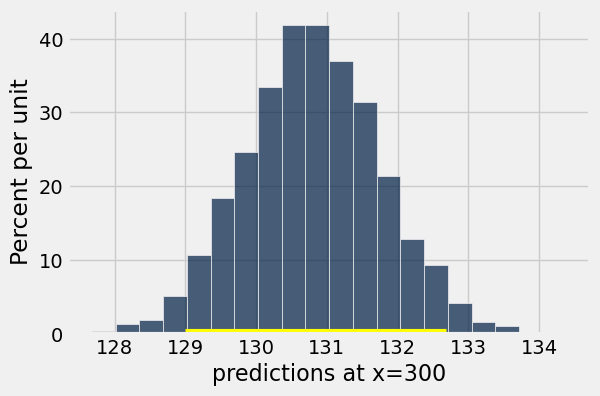

In [27]:
bootstrap_prediction(births, 'Gestational Days', 'Birth Weight', 300, 2500)

In [28]:
np.mean(births.column('Gestational Days'))

279.11015490533561

Height of the regression line at x=285: 122.742
Approximate 95%-confidence interval:
121.734 to 123.814


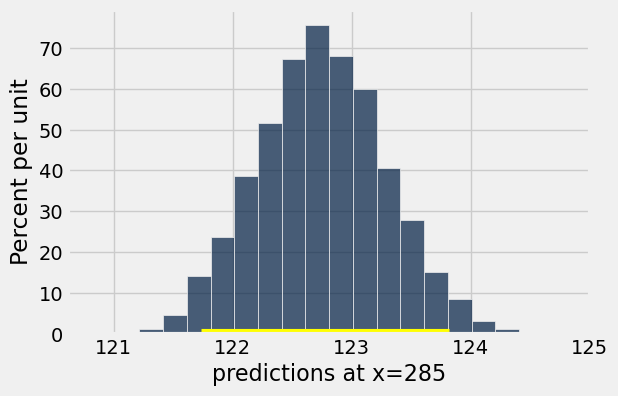

In [29]:
bootstrap_prediction(births, 'Gestational Days', 'Birth Weight', 285, 2500)

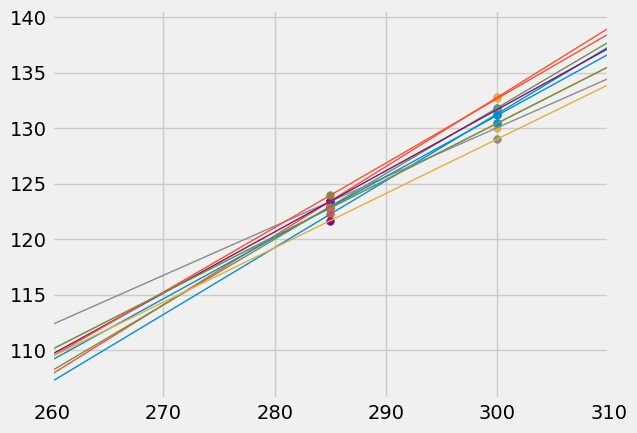

In [31]:
# predictions closer to the mean have less spread than predictions farther from the mean
x1 = 300
x2 = 285

lines = Table(['slope','intercept'])
for i in range(10):
    rep = births.sample(with_replacement=True)
    a = slope(rep, 'Gestational Days', 'Birth Weight')
    b = intercept(rep, 'Gestational Days', 'Birth Weight')
    lines.append([a, b])

xlims = np.array([260, 310])
left = xlims[0]*lines[0] + lines[1]
right = xlims[1]*lines[0] + lines[1]
fit_x1 = x1*lines['slope'] + lines['intercept']
fit_x2 = x2*lines['slope'] + lines['intercept']

plt.xlim(xlims)
for i in range(10):
    plt.plot(xlims, np.array([left[i], right[i]]), lw=1)
    plt.scatter(x1, fit_x1[i], s=30)
    plt.scatter(x2, fit_x2[i], s=30)

# Crushed ICE examples

In [32]:
sons_heights = Table.read_table('data/sons_heights.csv')
sons_heights

father,mother,son
78.5,67,73.2
75.5,66.5,73.5
75,64,71
75,64,70.5
75,58.5,72
74,68,76.5
74,62,74
73,67,71
73,67,68
73,66.5,71
